# Task 2: SQL and Python Integration
## Project Overview
This task focuses on using SQL for data extraction and analysis
and integrating SQL with Python for business data analysis.
## Objectives
- Perform SQL-based data analysis
- Practice basic and advanced SQL queries
- Work with a SQLite database
- Integrate SQL with Python
- Answer business-related questions using data

In [35]:
# Import Required Libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [3]:
import os
os.getcwd()

'D:\\APEXPLANET-DATA-ANALYTICS\\Task-2-SQL-Python\\notebooks'

In [4]:
# Load Cleaned Dataset
df = pd.read_csv("../../Task-1-EDA/data/cleaned_dataset.csv")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [5]:
df.shape

(1000, 12)

In [6]:
# Create SQLite Database
import sqlite3
connection = sqlite3.connect("../database/sales_analysis.db")
print("Database connected successfully!")

Database connected successfully!


In [7]:
# Load Data into SQLite Table
df.to_sql("sales", connection, if_exists="replace", index=False)
print("Data loaded into sales table successfully!")

Data loaded into sales table successfully!


In [8]:
# Check Data from SQL Table
query = """
SELECT *
FROM sales
LIMIT 5;
"""
pd.read_sql_query(query, connection)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [9]:
# Select All Records
query = """
SELECT *
FROM sales;
"""
result = pd.read_sql_query(query, connection)
result.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [10]:
# Select Specific Columns
query = """
SELECT Order_ID, Customer_Name, Product, Total_Sales
FROM sales;
"""
result = pd.read_sql_query(query, connection)
result.head()

,Order_ID,Customer_Name,Product,Total_Sales
0,ORD100002,Customer_227,Rice,19808.39
1,ORD100003,Customer_182,Book,139530.80
2,ORD100004,Customer_487,Book,299928.48
3,ORD100005,Customer_470,Mobile,256872.24
4,ORD100006,Customer_380,Rice,140365.90


In [11]:
# WHERE: Filter Records
query = """
SELECT *
FROM sales
WHERE Gender = 'Male';
"""
result = pd.read_sql_query(query, connection)
result.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
1,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90
2,ORD100008,2025-10-14,CUST1758,Customer_335,61.0,Male,Patna,Mobile,Electronics,6,49997.53,299985.18
3,ORD100009,2025-12-05,CUST9622,Customer_224,35.0,Male,Kolkata,Laptop,Electronics,3,9488.83,28466.49
4,ORD100011,2025-04-16,CUST1312,Customer_40,30.0,Male,Kolkata,Mobile,Electronics,8,18024.34,144194.72


In [12]:
# Orders with Total Sales Greater Than 200000
query = """
SELECT *
FROM sales
WHERE Total_Sales > 200000;
"""
result = pd.read_sql_query(query, connection)
result.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
1,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
2,ORD100007,2025-12-31,CUST3952,Customer_71,40.0,Female,Hyderabad,Laptop,Electronics,9,35947.47,323527.23
3,ORD100008,2025-10-14,CUST1758,Customer_335,61.0,Male,Patna,Mobile,Electronics,6,49997.53,299985.18
4,ORD100013,2025-05-02,CUST3228,Customer_209,55.0,Female,Patna,Chair,Furniture,6,47175.43,283052.58


In [13]:
# Sort Orders by Total Sales
query = """
SELECT Order_ID, Product, Total_Sales
FROM sales
ORDER BY Total_Sales DESC;
"""
result = pd.read_sql_query(query, connection)
result.head(10)

,Order_ID,Product,Total_Sales
0,ORD100052,Book,493677.5
1,ORD100764,Laptop,492174.1
2,ORD100222,Shoes,490866.4
3,ORD100974,Laptop,485667.8
4,ORD100624,Rice,482551.9
5,ORD100366,Mobile,474935.9
6,ORD100949,Book,473144.2
7,ORD100714,Mobile,470798.6
8,ORD100982,Rice,468522.0
9,ORD100658,Shoes,462701.3


In [14]:
# Category-wise Total Sales
query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""
result = pd.read_sql_query(query, connection)
result

,Category,Total_Sales
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [15]:
# Category-wise Average Sales
query = """
SELECT Category,
       AVG(Total_Sales) AS Average_Sales
FROM sales
GROUP BY Category
ORDER BY Average_Sales DESC;
"""
result = pd.read_sql_query(query, connection)
result

,Category,Average_Sales
0,Grocery,145305.302484
1,Electronics,143442.321186
2,Education,140627.468539
3,Furniture,135355.732579
4,Fashion,127153.178141


In [16]:
# HAVING: Filter Grouped Data

query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
HAVING SUM(Total_Sales) > 40000000
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, connection)
result

,Category,Total_Sales
0,Electronics,50778581.7


In [17]:
# Create Customer Table
customer_df = df[
    ["Customer_ID", "Customer_Name", "Gender", "Age", "City"]
].drop_duplicates("Customer_ID")
customer_df.to_sql(
    "customers",
    connection,
    if_exists="replace",
    index=False
)
print("Customers table created successfully!")

Customers table created successfully!


In [18]:
# Create Orders Table
orders_df = df[
    ["Order_ID", "Customer_ID", "Product", "Category",
     "Quantity", "Unit_Price", "Total_Sales", "Order_Date"]
]
orders_df.to_sql(
    "orders",
    connection,
    if_exists="replace",
    index=False
)
print("Orders table created successfully!")

Orders table created successfully!


In [19]:
# INNER JOIN: Customers and Orders

query = """
SELECT
    c.Customer_Name,
    c.City,
    o.Product,
    o.Total_Sales
FROM customers c
INNER JOIN orders o
    ON c.Customer_ID = o.Customer_ID
LIMIT 10;
"""
result = pd.read_sql_query(query, connection)
result

,Customer_Name,City,Product,Total_Sales
0,Customer_227,Bengaluru,Rice,19808.39
1,Customer_182,Bengaluru,Book,139530.80
2,Customer_487,Bengaluru,Book,299928.48
3,Customer_470,Kolkata,Mobile,126104.76
4,Customer_470,Kolkata,Mobile,256872.24
5,Customer_470,Kolkata,Shoes,48215.86
6,Customer_380,Bengaluru,Rice,140365.90
7,Customer_71,Hyderabad,Laptop,323527.23
8,Customer_335,Patna,Mobile,299985.18
9,Customer_224,Kolkata,Laptop,28466.49


In [20]:
# LEFT JOIN: Customers and Orders

query = """
SELECT
    c.Customer_ID,
    c.Customer_Name,
    c.City,
    o.Order_ID,
    o.Product,
    o.Total_Sales
FROM customers c
LEFT JOIN orders o
    ON c.Customer_ID = o.Customer_ID
LIMIT 10;
"""
result = pd.read_sql_query(query, connection)
result

,Customer_ID,Customer_Name,City,Order_ID,Product,Total_Sales
0,CUST5529,Customer_227,Bengaluru,ORD100002,Rice,19808.39
1,CUST3127,Customer_182,Bengaluru,ORD100003,Book,139530.80
2,CUST8887,Customer_487,Bengaluru,ORD100004,Book,299928.48
3,CUST2515,Customer_470,Kolkata,ORD100005,Mobile,256872.24
4,CUST2515,Customer_470,Kolkata,ORD100542,Shoes,48215.86
5,CUST2515,Customer_470,Kolkata,ORD100556,Mobile,126104.76
6,CUST4796,Customer_380,Bengaluru,ORD100006,Rice,140365.90
7,CUST3952,Customer_71,Hyderabad,ORD100007,Laptop,323527.23
8,CUST1758,Customer_335,Patna,ORD100008,Mobile,299985.18
9,CUST9622,Customer_224,Kolkata,ORD100009,Laptop,28466.49


In [21]:
# Customer-wise Total Spending

query = """
SELECT
    c.Customer_ID,
    c.Customer_Name,
    c.City,
    SUM(o.Total_Sales) AS Total_Spending
FROM customers c
LEFT JOIN orders o
    ON c.Customer_ID = o.Customer_ID
GROUP BY
    c.Customer_ID,
    c.Customer_Name,
    c.City
ORDER BY Total_Spending DESC;
"""
result = pd.read_sql_query(query, connection)
result.head(10)

,Customer_ID,Customer_Name,City,Total_Spending
0,CUST9510,Customer_345,Kolkata,867333.24
1,CUST6845,Customer_337,Hyderabad,769479.75
2,CUST6532,Customer_348,Pune,610981.74
3,CUST6082,Customer_301,Mumbai,548416.39
4,CUST3689,Customer_179,Delhi,542484.08
5,CUST3730,Customer_273,Patna,538633.97
6,CUST4706,Customer_34,Delhi,528036.44
7,CUST9693,Customer_343,Patna,511421.86
8,CUST7374,Customer_375,Patna,511309.40
9,CUST2062,Customer_254,Patna,493677.50


In [22]:
# Orders with Sales Above Average
query = """
SELECT Order_ID, Product, Total_Sales
FROM sales
WHERE Total_Sales > (
    SELECT AVG(Total_Sales)
    FROM sales
)
ORDER BY Total_Sales DESC;
"""
result = pd.read_sql_query(query, connection)
result.head(10)

,Order_ID,Product,Total_Sales
0,ORD100052,Book,493677.5
1,ORD100764,Laptop,492174.1
2,ORD100222,Shoes,490866.4
3,ORD100974,Laptop,485667.8
4,ORD100624,Rice,482551.9
5,ORD100366,Mobile,474935.9
6,ORD100949,Book,473144.2
7,ORD100714,Mobile,470798.6
8,ORD100982,Rice,468522.0
9,ORD100658,Shoes,462701.3


In [23]:
# Order with Highest Sales
query = """
SELECT Order_ID, Product, Total_Sales
FROM sales
WHERE Total_Sales = (
    SELECT MAX(Total_Sales)
    FROM sales
);
"""
result = pd.read_sql_query(query, connection)
result

,Order_ID,Product,Total_Sales
0,ORD100052,Book,493677.5


In [24]:
# Category-wise Sales using CTE
query = """
WITH category_sales AS (
    SELECT Category,
           SUM(Total_Sales) AS Total_Sales
    FROM sales
    GROUP BY Category
)
SELECT *
FROM category_sales
ORDER BY Total_Sales DESC;
"""
result = pd.read_sql_query(query, connection)
result

,Category,Total_Sales
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [25]:
# Top Categories using CTE
query = """
WITH category_sales AS (
    SELECT Category,
           SUM(Total_Sales) AS Total_Sales
    FROM sales
    GROUP BY Category
)
SELECT *
FROM category_sales
ORDER BY Total_Sales DESC
LIMIT 3;
"""
result = pd.read_sql_query(query, connection)
result

,Category,Total_Sales
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28


In [26]:
#Rank Products by Sales
query = """
SELECT
    Product,
    SUM(Total_Sales) AS Total_Sales,
    RANK() OVER (
        ORDER BY SUM(Total_Sales) DESC
    ) AS Sales_Rank
FROM sales
GROUP BY Product;
"""
result = pd.read_sql_query(query, connection)
result

,Product,Total_Sales,Sales_Rank
0,Laptop,25443008.51,1
1,Mobile,25335573.19,2
2,Book,25031689.40,3
3,Rice,22231711.28,4
4,Chair,21521561.48,5
5,Shoes,19835895.79,6


In [27]:
# Monthly Sales
query = """
SELECT
    substr(Order_Date, 1, 7) AS Month,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""
result = pd.read_sql_query(query, connection)
result

,Month,Total_Sales
0,2025-01,10096190.73
1,2025-02,11511181.46
2,2025-03,13059899.94
3,2025-04,12222700.17
4,2025-05,10984689.25
5,2025-06,12912332.64
6,2025-07,11746226.80
7,2025-08,9448471.22
8,2025-09,9179896.29
9,2025-10,12500936.50


In [28]:
# Top 5 Products by Sales
query = """
SELECT
    Product,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
LIMIT 5;
"""
result = pd.read_sql_query(query, connection)
result

,Product,Total_Sales
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48


In [29]:
#Overall Business Summary
query = """
SELECT
    COUNT(*) AS Total_Orders,
    SUM(Quantity) AS Total_Quantity,
    SUM(Total_Sales) AS Total_Sales,
    AVG(Total_Sales) AS Average_Order_Value,
    MAX(Total_Sales) AS Highest_Order_Value
FROM sales;
"""
result = pd.read_sql_query(query, connection)
result

,Total_Orders,Total_Quantity,Total_Sales,Average_Order_Value,Highest_Order_Value
0,1000,5435,1.393994e+08,139399.43965,493677.5


***Python + SQL Integration***

In [30]:
# Q1: SQL Query Result in Pandas
query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""
category_result = pd.read_sql_query(query, connection)
category_result

,Category,Total_Sales
0,Electronics,50778581.70
1,Education,25031689.40
2,Grocery,22231711.28
3,Furniture,21521561.48
4,Fashion,19835895.79


In [31]:
# Q2: SQL + Python Calculation
query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""
category_result = pd.read_sql_query(query, connection)
total_sales = category_result["Total_Sales"].sum()
highest_sales = category_result["Total_Sales"].max()
print("Total Sales:", total_sales)
print("Highest Category Sales:", highest_sales)

Total Sales: 139399439.65
Highest Category Sales: 50778581.7


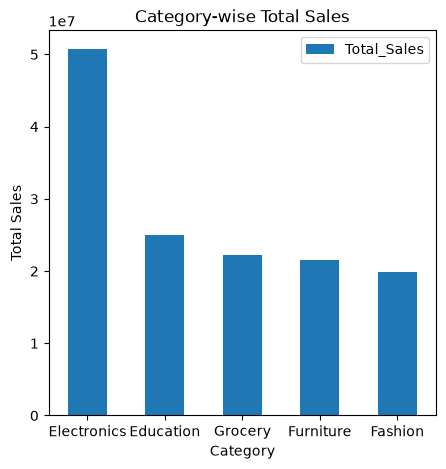

In [36]:
# Q3: SQL + Python Visualization
query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""
category_result = pd.read_sql_query(query, connection)
category_result.plot(
    x="Category",
    y="Total_Sales",
    kind="bar",
    figsize=(5, 5),
    title="Category-wise Total Sales"
)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [37]:
# Q4: Top 5 Products and Sales Percentage
query = """
SELECT Product,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Product
ORDER BY Total_Sales DESC
LIMIT 5;
"""
top_products = pd.read_sql_query(query, connection)
top_products["Sales_Percentage"] = (
    top_products["Total_Sales"]
    / top_products["Total_Sales"].sum()
) * 100
top_products

,Product,Total_Sales,Sales_Percentage
0,Laptop,25443008.51,21.279905
1,Mobile,25335573.19,21.190049
2,Book,25031689.40,20.935888
3,Rice,22231711.28,18.594055
4,Chair,21521561.48,18.000103


In [38]:
# Q5: Monthly Sales Business Analysis
query = """
SELECT
    substr(Order_Date, 1, 7) AS Month,
    SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Month
ORDER BY Month;
"""
monthly_result = pd.read_sql_query(query, connection)
highest_month = monthly_result.loc[
    monthly_result["Total_Sales"].idxmax()
]
print("Highest Sales Month:", highest_month["Month"])
print("Sales:", highest_month["Total_Sales"])

Highest Sales Month: 2025-03
Sales: 13059899.94
